In [ ]:
#imports
import json
import matplotlib.pyplot as plt
import pandas as pd
import glob

Found 3 JSON files


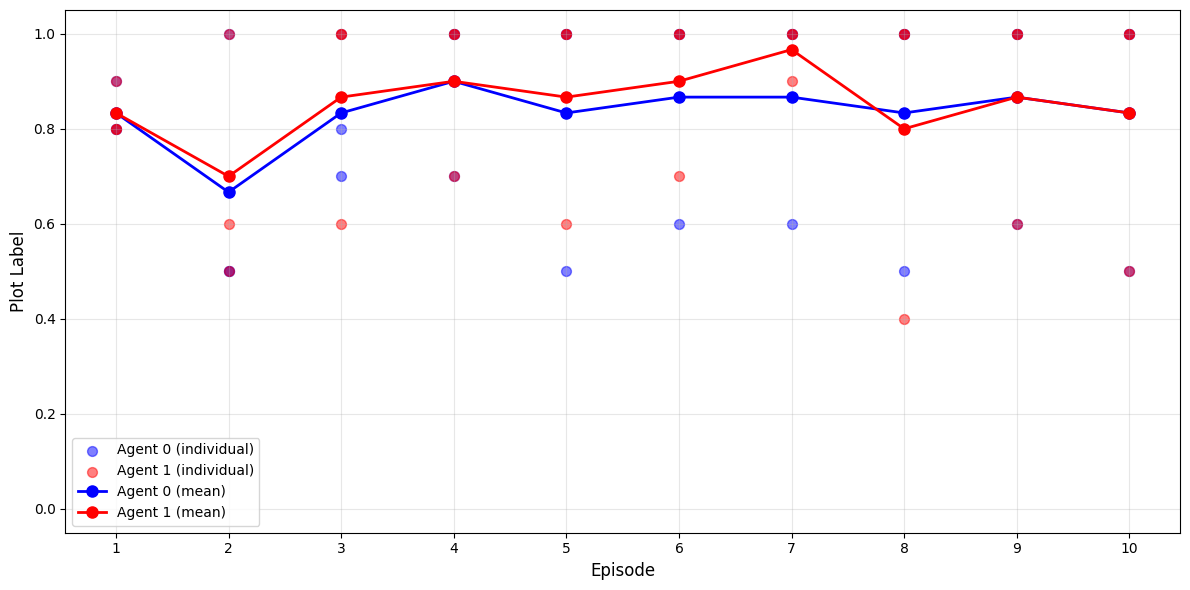


Mean cooperation rates by episode:
         agent_0_coop_rate  agent_1_coop_rate
episode                                      
1                 0.833333           0.833333
2                 0.666667           0.700000
3                 0.833333           0.866667
4                 0.900000           0.900000
5                 0.833333           0.866667
6                 0.866667           0.900000
7                 0.866667           0.966667
8                 0.833333           0.800000
9                 0.866667           0.866667
10                0.833333           0.833333


In [ ]:
# NEW CODE TO PROCESS EXPERIMENT JSON FILES AND PRODUCE GRAPHICAL OUTPUT @edc
PLOTLABEL = "Plot Label"

# Get all JSON files
json_files = glob.glob('results/episodic_game_20260228_145843*.json')  # Adjust pattern if needed
print(f"Found {len(json_files)} JSON files")

# Collect all cooperation rates
all_data = []

for json_file in json_files:
    with open(json_file) as f:
        data = json.load(f)
    
    # Extract episode-level cooperation rates from this simulation
    for episode_data in data['episodes']:
        all_data.append({
            'simulation': json_file,
            'episode': episode_data['episode'],
            'agent_0_coop_rate': episode_data['agent_0']['cooperation_rate'],
            'agent_1_coop_rate': episode_data['agent_1']['cooperation_rate']
        })

df = pd.DataFrame(all_data)


# Calculate means by episode
means = df.groupby('episode')[['agent_0_coop_rate', 'agent_1_coop_rate']].mean()

# Create the scatter plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot individual points (scatter)
ax.scatter(df['episode'], df['agent_0_coop_rate'], 
           color='blue', alpha=0.5, s=50, label='Agent 0 (individual)')
ax.scatter(df['episode'], df['agent_1_coop_rate'], 
           color='red', alpha=0.5, s=50, label='Agent 1 (individual)')

# Plot mean lines
ax.plot(means.index, means['agent_0_coop_rate'], 
        color='blue', linewidth=2, marker='o', markersize=8, 
        label='Agent 0 (mean)')
ax.plot(means.index, means['agent_1_coop_rate'], 
        color='red', linewidth=2, marker='o', markersize=8,
        label='Agent 1 (mean)')

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel(PLOTLABEL, fontsize=12)
ax.set_title('', fontsize=14)
ax.set_ylim(-0.05, 1.05)
ax.set_xticks(range(1, 11))
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nMean cooperation rates by episode:")
print(means)